# <a id='toc1_'></a>[Extracting and Visualising Stock Data](#toc0_)
**Web Scraping, REST APIs and Requests**

**Table of contents**<a id='toc0_'></a>    
- [Extracting and Visualising Stock Data](#toc1_)    
  - [Scenario](#toc1_1_)    
  - [Objective](#toc1_2_)    
  - [Imports](#toc1_3_)    
  - [Using yfinance to extract Stock Market Data for Tesla](#toc1_4_)    
    - [Tesla (TSLA)](#toc1_4_1_)    
  - [Using Web Scraping to extract Tesla Revenue Data](#toc1_5_)    
  - [Using yfinance to extract Stock Market Data for GameStop](#toc1_6_)    
    - [GameStop (GME)](#toc1_6_1_)    
  - [Using Webscraping to extract GameStop Revenue Data](#toc1_7_)    
  - [Visualising Stock Graphs](#toc1_8_)    
    - [Helper Function](#toc1_8_1_)    
    - [Tesla (TSLA)](#toc1_8_2_)    
    - [GameStop (GME)](#toc1_8_3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Scenario](#toc0_)

In this scenario I am in the role of a Data Scientist working for a startup investment firm. The investment firm helps customers to make informed decisions about investing into the stock market.

## <a id='toc1_2_'></a>[Objective](#toc0_)

My objective is to extract the financial data, such as the historical stock prices and quarterly revenue from multiple sources using Python libraries and web scraping techniques. This will then be visualised in a dashboard to identify patterns and trends.

I will be working with the following stocks:
* Tesla
* GameStop

## <a id='toc1_3_'></a>[Imports](#toc0_)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import warnings
from io import StringIO

In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)

## <a id='toc1_4_'></a>[Using yfinance to extract Stock Market Data for Tesla](#toc0_)

### <a id='toc1_4_1_'></a>[Tesla (TSLA)](#toc0_)

Using the `Ticker()` function in order to create a ticker object. For Tesla its ticker symbol is TSLA.

In [3]:
tesla = yf.Ticker('TSLA')

We can then use this ticker object to get more information and data about Tesla.

In [4]:
tesla.info

{'address1': '1 Tesla Road',
 'city': 'Austin',
 'state': 'TX',
 'zip': '78725',
 'country': 'United States',
 'phone': '512 516 8177',
 'website': 'https://www.tesla.com',
 'industry': 'Auto Manufacturers',
 'industryKey': 'auto-manufacturers',
 'industryDisp': 'Auto Manufacturers',
 'sector': 'Consumer Cyclical',
 'sectorKey': 'consumer-cyclical',
 'sectorDisp': 'Consumer Cyclical',
 'longBusinessSummary': 'Tesla, Inc. designs, develops, manufactures, leases, and sells electric vehicles, and energy generation and storage systems in the United States, China, and internationally. The company operates in two segments, Automotive; and Energy Generation and Storage. The company offers electric vehicles, as well as sells automotive regulatory credits; and non-warranty maintenance services and collision, automotive insurance services, as well as part sales and retail merchandise sale. It also provides sedans and sport utility vehicles through direct and used vehicle sales, a network of Tesl

In [5]:
tesla.income_stmt

,2025-12-31,2024-12-31,2023-12-31,2022-12-31,2021-12-31
Tax Effect Of Unusual Items,-1.333800e+08,-1.368000e+08,0.000000e+00,-1.408000e+07,NaN
Tax Rate For Calcs,2.700000e-01,2.000000e-01,2.100000e-01,8.000000e-02,NaN
Normalized EBITDA,1.225800e+10,1.539200e+10,1.479600e+10,1.783300e+10,NaN
Total Unusual Items,-4.940000e+08,-6.840000e+08,0.000000e+00,-1.760000e+08,NaN
Total Unusual Items Excluding Goodwill,-4.940000e+08,-6.840000e+08,0.000000e+00,-1.760000e+08,NaN
Net Income From Continuing Operation Net Minority Interest,3.794000e+09,7.130000e+09,1.499900e+10,1.258300e+10,NaN
Reconciled Depreciation,6.148000e+09,5.368000e+09,4.667000e+09,3.747000e+09,NaN
Reconciled Cost Of Revenue,7.773300e+10,8.024000e+10,7.911300e+10,6.060900e+10,NaN
EBITDA,1.176400e+10,1.470800e+10,1.479600e+10,1.765700e+10,NaN
EBIT,5.616000e+09,9.340000e+09,1.012900e+10,1.391000e+10,NaN


In [6]:
tesla.balance_sheet

,2025-12-31,2024-12-31,2023-12-31,2022-12-31,2021-12-31
Treasury Shares Number,NaN,NaN,0.000000e+00,NaN,NaN
Ordinary Shares Number,3.751000e+09,3.216000e+09,3.185000e+09,3.164000e+09,NaN
Share Issued,3.751000e+09,3.216000e+09,3.185000e+09,3.164000e+09,NaN
Total Debt,1.471900e+10,1.362300e+10,9.573000e+09,5.748000e+09,NaN
Tangible Book Value,8.074800e+10,7.144300e+10,6.201900e+10,4.411100e+10,NaN
...,...,...,...,...,...
Cash Cash Equivalents And Short Term Investments,4.405900e+10,3.656300e+10,2.909400e+10,2.218500e+10,NaN
Other Short Term Investments,2.754600e+10,2.042400e+10,1.269600e+10,5.932000e+09,NaN
Cash And Cash Equivalents,1.651300e+10,1.613900e+10,1.639800e+10,1.625300e+10,NaN
Cash Equivalents,1.890000e+09,1.753000e+09,4.950000e+08,2.288000e+09,NaN


Using the `history()` method to extract the stock data and store in a dataframe named `tesla_data` with a time length set to the maximum amount of time.

In [7]:
tesla_data = tesla.history(period='max')

In [8]:
tesla_data.reset_index(inplace=True)
tesla_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


## <a id='toc1_5_'></a>[Using Web Scraping to extract Tesla Revenue Data](#toc0_)

Here we will use the `request` library to send a HTTP GET Request to the webpage where our Tesla data is hosted.

We will be getting the Tesla Revenue Data from macrotrends, and so lets check its `robots.txt` file to see its permissions.

[Robots.txt](robots.pdf)

In the `macrotrends.net/robots.txt` file it only disallows certain file paths, these being:

![Robots](Robots.png)

With our url file path containing `/stocks/charts` we are therefore allowed to scrape the webpage.

In [9]:
url = 'https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue'
headers = {'User-Agent': 'Mozilla/5.0'}
r = requests.get(url, headers=headers)

In [10]:
r.status_code

200

In [11]:
data = r.text

Now using BeautifulSoup, we will parse the HTML document with the `html5lib` parser.

In [12]:
tesla_rev = BeautifulSoup(data, 'html5lib')

With this Soup object of `tesla_rev` we will now find the table where our quarterly revenue is.

When looking at the webpage and inspecting element, we use ctrl+f to find and search for table. Doing this we find that the table we want is in the 2 position out of 11. With Python's 0 based Indexing, this means it is in index 1.

![Tesla](Tesla_Revenue_Inspect_Element.png)

In [13]:
table = tesla_rev.find_all('tbody')[1]

In [14]:
tesla_revenue = pd.DataFrame(columns=['Date', 'Revenue'])

In [15]:
for row in table.find_all('tr'):
    col = row.find_all('td')
    date = col[0].text
    revenue = col[1].text
    tesla_revenue = pd.concat([tesla_revenue, pd.DataFrame({'Date': [date],
                                                            'Revenue': [revenue]}
                                                            )], ignore_index=True)

In [16]:
tesla_revenue.head()

,Date,Revenue
0,2026-03-31,"$22,387"
1,2025-12-31,"$24,901"
2,2025-09-30,"$28,095"
3,2025-06-30,"$22,496"
4,2025-03-31,"$19,335"


Lets clean the `Revenue` column

In [17]:
tesla_revenue['Revenue'] = tesla_revenue['Revenue'].str.replace(',|\$', "", regex=True)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\alexa\AppData\Local\Temp\ipykernel_24156\3524225392.py:1: SyntaxWarning: invalid escape sequence '\$'
  tesla_revenue['Revenue'] = tesla_revenue['Revenue'].str.replace(',|\$', "", regex=True)


In [18]:
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

Displaying the last 5 rows of the `tesla_revenue` dataframe

In [19]:
tesla_revenue.tail()

,Date,Revenue
55,2012-06-30,27
56,2012-03-31,30
57,2011-12-31,39
58,2011-09-30,58
59,2011-06-30,58


## <a id='toc1_6_'></a>[Using yfinance to extract Stock Market Data for GameStop](#toc0_)

### <a id='toc1_6_1_'></a>[GameStop (GME)](#toc0_)

We will repeat the previous tasks of using the `Ticker()` function and getting the data for GameStop

In [20]:
gamestop = yf.Ticker('GME')

Lets look at GameStops information

In [21]:
gamestop.info

{'address1': '625 Westport Parkway',
 'city': 'Grapevine',
 'state': 'TX',
 'zip': '76051',
 'country': 'United States',
 'phone': '817 424 2000',
 'website': 'https://www.gamestop.com',
 'industry': 'Specialty Retail',
 'industryKey': 'specialty-retail',
 'industryDisp': 'Specialty Retail',
 'sector': 'Consumer Cyclical',
 'sectorKey': 'consumer-cyclical',
 'sectorDisp': 'Consumer Cyclical',
 'longBusinessSummary': 'GameStop Corp., a specialty retailer, provides games, collectibles, and entertainment products through its stores and e-commerce platforms in United States, Australia and Europe. The company sells new and pre-owned gaming platforms; accessories, such as controllers, gaming headsets, and other peripheral devices; new and pre-owned gaming software; and in-game digital currency, digital downloadable content, and full-game downloads. It also sells collectibles comprising apparel, toys, trading cards, gadgets, and other retail products for pop culture and technology enthusiasts

In [22]:
gamestop.income_stmt

,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Tax Effect Of Unusual Items,-7.416000e+07,-4.171283e+05,-1.008000e+06,-5.670000e+05,NaN
Tax Rate For Calcs,4.000000e-01,4.300300e-02,2.100000e-01,2.100000e-01,NaN
Normalized EBITDA,4.859000e+08,3.210000e+07,3.130000e+07,-2.445000e+08,NaN
Total Unusual Items,-1.854000e+08,-9.700000e+06,-4.800000e+06,-2.700000e+06,NaN
Total Unusual Items Excluding Goodwill,-1.854000e+08,-9.700000e+06,-4.800000e+06,-2.700000e+06,NaN
Net Income From Continuing Operation Net Minority Interest,4.184000e+08,1.313000e+08,6.700000e+06,-3.131000e+08,NaN
Reconciled Depreciation,1.460000e+07,3.890000e+07,5.620000e+07,6.170000e+07,NaN
Reconciled Cost Of Revenue,2.433800e+09,2.709100e+09,3.978600e+09,4.555100e+09,NaN
EBITDA,3.005000e+08,2.240000e+07,2.650000e+07,-2.472000e+08,NaN
EBIT,2.859000e+08,-1.650000e+07,-2.970000e+07,-3.089000e+08,NaN


In [23]:
gamestop.balance_sheet

,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Ordinary Shares Number,4.483000e+08,4.468004e+08,3.057000e+08,3.046000e+08,NaN
Share Issued,4.483000e+08,4.468004e+08,3.057000e+08,3.046000e+08,NaN
Total Debt,4.361900e+09,4.107000e+08,6.028000e+08,6.166000e+08,NaN
Tangible Book Value,5.444400e+09,4.929800e+09,1.338600e+09,1.322300e+09,NaN
Invested Capital,9.608700e+09,4.946700e+09,1.367100e+09,1.361800e+09,NaN
...,...,...,...,...,...
Allowance For Doubtful Accounts Receivable,-4.200000e+06,-4.700000e+06,-4.400000e+06,-2.200000e+06,NaN
Gross Accounts Receivable,4.920000e+07,6.560000e+07,9.540000e+07,1.561000e+08,NaN
Cash Cash Equivalents And Short Term Investments,9.013800e+09,4.774900e+09,1.199300e+09,1.390600e+09,NaN
Other Short Term Investments,2.709100e+09,1.800000e+07,2.776000e+08,2.516000e+08,NaN


Using the ticker object to get the share price data

In [24]:
gme_data = gamestop.history(period='max')

In [25]:
gme_data.reset_index(inplace=True)

In [26]:
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683251,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


## <a id='toc1_7_'></a>[Using Webscraping to extract GameStop Revenue Data](#toc0_)

The webpage is again a macrotrends webpage and so we know from its `robots.txt` file the permitted file paths with our path of `/stocks/charts/` being permitted.

In [27]:
url = 'https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue'
headers = {'User-Agent': 'Mozilla/5.0'}
r = requests.get(url, headers=headers)

In [28]:
r.status_code

200

In [29]:
response = r.text

In [30]:
gme_soup = BeautifulSoup(response, 'html5lib')

This time instead of using BeautifulSoup entirely, we will use pandas `read_html` funciton.

When looking at the macrotrends webpage and using ctrl+f when inspecting element to find the tables, we can see that it is the 2nd out of 38 tables. With Python's 0 based indexing this means it is at index 1.

![GameStop](GameStop_Revenue_Inspect_Element.png)

In [31]:
tables = gme_soup.find_all('table')
gme_revenue = pd.read_html(StringIO(str(tables[1])), flavor='bs4')[0]
gme_revenue.head()

,GameStop Quarterly Revenue (Millions of US $),GameStop Quarterly Revenue (Millions of US $).1
0,2026-01-31,"$1,104"
1,2025-10-31,$821
2,2025-07-31,$972
3,2025-04-30,$732
4,2025-01-31,"$1,283"


Now lets clean the dataframe

In [32]:
gme_revenue.columns

Index(['GameStop Quarterly Revenue (Millions of US $)', 'GameStop Quarterly Revenue (Millions of US $).1'], dtype='object')

In [33]:
gme_revenue.columns = ['Date', 'Revenue']
gme_revenue.columns

Index(['Date', 'Revenue'], dtype='object')

In [34]:
gme_revenue.head()

,Date,Revenue
0,2026-01-31,"$1,104"
1,2025-10-31,$821
2,2025-07-31,$972
3,2025-04-30,$732
4,2025-01-31,"$1,283"


In [35]:
gme_revenue['Revenue'] = gme_revenue['Revenue'].str.replace(',|\$', "", regex=True)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\alexa\AppData\Local\Temp\ipykernel_24156\2709528454.py:1: SyntaxWarning: invalid escape sequence '\$'
  gme_revenue['Revenue'] = gme_revenue['Revenue'].str.replace(',|\$', "", regex=True)


In [36]:
gme_revenue['Revenue'].dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

In [37]:
gme_revenue.tail()

,Date,Revenue
54,2012-07-31,1550
55,2012-04-30,2002
56,2012-01-31,3579
57,2011-10-31,1947
58,2011-07-31,1744


## <a id='toc1_8_'></a>[Visualising Stock Graphs](#toc0_)

### <a id='toc1_8_1_'></a>[Helper Function](#toc0_)

This helper function called `make_graph` will take a dataframe with stock market data, a dataframe with stock revenue data and the name of the stock. The dataframe for the stock market data must contain a `Date` and `Close` column, and the dataframe for the stock revenue must contain a `Date` and `Revenue` column.

In [38]:
def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

### <a id='toc1_8_2_'></a>[Tesla (TSLA)](#toc0_)

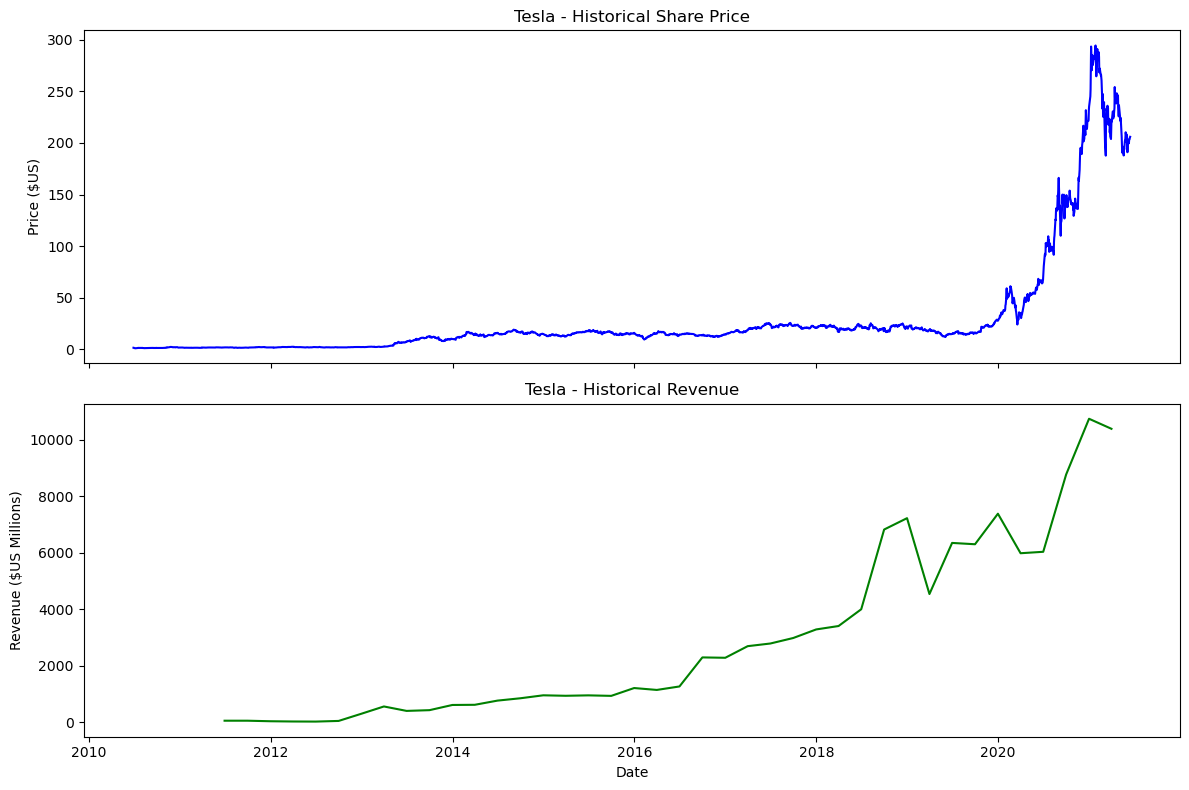

In [39]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

### <a id='toc1_8_3_'></a>[GameStop (GME)](#toc0_)

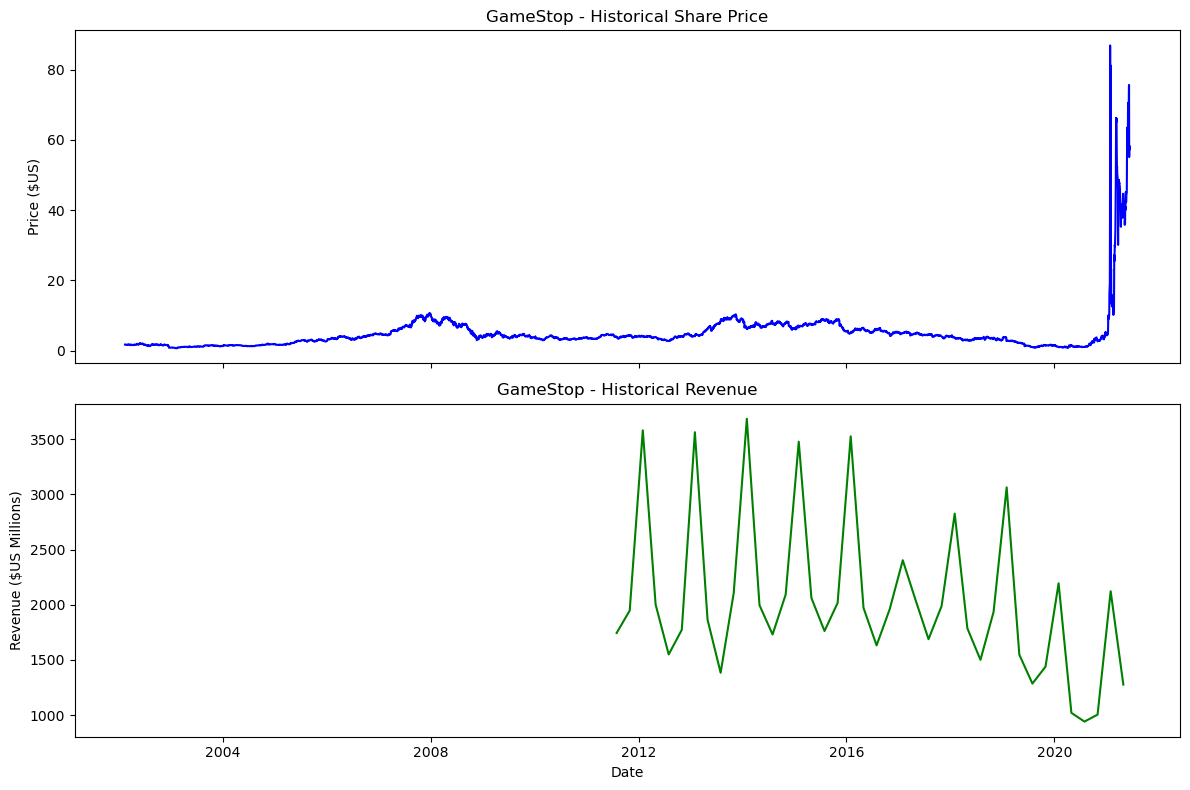

In [40]:
make_graph(gme_data, gme_revenue, 'GameStop')

Here we can see that for Tesla as the share price increased so did the revenue as well, thereby indicating that the increase in revenue contributed towards the increase in the share price for Tesla. In contrast, for GameStop the share price increased but the revenue was hectic. This was due to redittors on the subreddit WallStreetBets buying huge amounts of Gamestop stock which in turn led to the share price sharply increasing.